# Test Approximation

## Imports

In [7]:
from math import e, log, sqrt, pi
from statistics import NormalDist
from hashlib import sha256
import mmh3
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
import csv
from utils import *

## Constants

In [8]:
N = 2 ** 16
p = 1 - e**(-2) # our table coverage
t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

## Functions

### Hash and Reduction

In [9]:
def H(x):
    return sha256(x.to_bytes(8, 'little')).digest()  # return bytes directly

def r(y, i, ell=0):
    return mmh3.hash(y, i + ell*t, signed=False) % N

### Approximation

In [10]:
# the same k is used for all columns
def approximate_mt(N, t, K, m_0):
    m = m_0  # starting m value

    # for the number of columns
    for i in range(t):
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m

        # calculate the statistical average of m_i
        average = N * (1 - E1)

        # find variance, and thus standard deviation
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((K - pi / 8) / (K - pi / 4 + 1)) * sd

    return m


### Actual 

In [11]:
# basically makes a cherry table
def actual_mt(N, t, K, m_0, startpoints):

    table = {sp: sp for sp in startpoints}  # store all the points then remove duplicate entries - can't do duplicate keys in dictionary anyway so we can just store all ep:sp

    # Instead of making the table chain by chain, we have to make it column by column to test what reduction function to choose
    # store reduction function indexes
    rf_indexes = []

    # for each column
    for i in tqdm(range(t), desc=f"Calculating columns: "):

        # variable to store best cherry-pick
        best_trial = -1

        # hash all current points then store with startpoints - this stores all our current points
        hashed_points = {H(mi): sp for mi, sp in table.items()}

        # we are going to continuously replace table with the best rf trial, so we empty it for now
            # we haven't lost the current points as we have them hashed in the hashed_points dictionary
        table = {}

        # get # cherry-picks for this column
        k_i = K

        # trial all the reduction functions for this column
        # for rf_trial in tqdm(range(k_i), desc=f"Choosing best RF: "):
        for rf_trial in range(k_i):

            # create a trial column to store results of current trial
            trial_column = {}

            # go through each key in hashed_points and store its reduction with sp
            for x in hashed_points:
                # reduce the hash and store in column
                trial_column[r(x, rf_trial)] = hashed_points[x]

            # if trial_column is bigger than current table stored, we replace it
            if len(trial_column) > len(table):
                # replace it 
                table = trial_column
                # replace best cherry-pick
                best_trial = rf_trial

        # now store the best rf cherry pick
        rf_indexes.append(best_trial)
        
    return len(table)

## Replicate Experiments

To check it works

In [12]:


# calculate the approximation line
m_0 = 1598
res = [0]

for K in tqdm(range(1, 1001)):
    res.append(approximate_mt(N, t, K, m_0))

100%|██████████| 1000/1000 [00:00<00:00, 6935.66it/s]


In [13]:


# find the experiment results
N_Experiment = 10 # number of experiments
res_actual = []

for K in [200, 400, 600, 800, 1000]:
    endpoints = []
    for i in range (N_Experiment):

        # make startpoints random
        startpoints = random.sample(range(N), m_0)
        endpoints.append(actual_mt(N, t, K, m_0, startpoints))

    res_actual.append(endpoints)

Calculating columns:   0%|          | 0/80 [00:00<?, ?it/s]

Calculating columns: 100%|██████████| 80/80 [00:37<00:00,  2.12it/s]


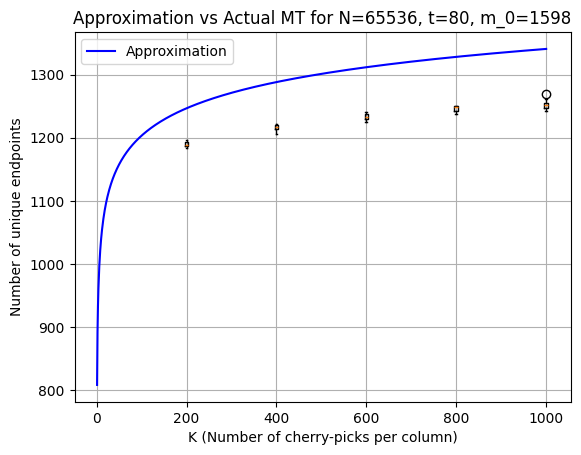

In [14]:


# plot the results
plt.plot(range(1, 1001), res[1:], label="Approximation", color='blue')
# plt.plot([10, 20, 50, 100, 200, 500  ], [sum(x)/N_Experiment for x in res_actual], label="Actual MT", color='red')
# boxplot for actual MT
plt.boxplot(res_actual, positions=[200, 400, 600, 800, 1000], widths=8, manage_ticks=False)

plt.xlabel("K (Number of cherry-picks per column)")
plt.ylabel("Number of unique endpoints")
plt.title(f"Approximation vs Actual MT for N={N}, t={t}, m_0={m_0}")
plt.grid(True)
plt.legend()    
plt.show()

In [15]:
# # sample 1000 each column, but as t goes on plot what the actual m is versus the approximation
# # calculate the approximation line
# m_0 = 1598
# res = [0]
# K = [1000] * t
# m = m_0
# for i in range(0, 81):
#     res.append(approximate_mt(N, i, K, m_0))
#     m = res[-1]

# # find the experiment results
# N_Experiment = 10 # number of experiments
# res_actual = []

# for K in [10, 20, 50, 100, 200, 500]:
#     endpoints = []
#     for i in range (N_Experiment):

#         # make startpoints random
#         startpoints = random.sample(range(N), m_0)
#         endpoints.append(actual_mt(N, t, K, m_0, startpoints))

#     res_actual.append(endpoints)

## Test 1

Plot box plots of actual tables v approximation
For each alpha, get the K values that the optimiser produced, then use these in the approximation formula
Hoping to see them line up/approximations within box plot ranges
Because its not, maybe something is going on with the approximation

### Get Approximations

In [16]:
%%script false

optimisation_mt = []
K_is = []

with open("cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    results = pickle.load(f)
    for result in results:
        optimisation_mt.append(result[3][-1])  # get the last m_t
        K_is.append(result[0])  # get the K used


# get approximation results
approximation_mt = []
for alpha in alphas:

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0

    K = K_is[alphas.index(alpha)]
    approximation_mt.append(approximate_mt(N, t, K, m_0))

Couldn't find program: 'false'


### Plot

In [17]:
%%script false

# Plot box plot of actual MT results

x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

data_cherry = pd.read_csv("cherry_N_16_10_trials_different_alpha_0.5_0.95_with_cost_results.csv")

# # scatter plot for simulated optimisation mt
# plt.plot(x_indicies, optimisation_mt, color='orange', label='Optimisation $m_t$', zorder=2, linestyle='--', marker='o')
# scatter plot for approximation mt
plt.plot(x_indicies, approximation_mt, color='green', label='Approximation of $m_t$', zorder=2, linestyle='--', marker='o')
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),      
            medianprops=dict(color='dodgerblue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))

# plot means of boxplots
plt.plot(x_indicies, [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten().mean() for alpha in alphas], 
         color='dodgerblue', marker='D', linestyle='--', label='Actual $m_t$', zorder=3)

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Cherry Tables ($N=2^{16}$, Cost factor = 5)', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()  
plt.show()

Couldn't find program: 'false'


## Test 2

Find average K values to use, so that for each alpha the same K are used. I am hoping this will allow us to compare the approximations to different start points better as using the same K makes the different alphas more comparable, and we can see what happens as we increase startpoints.

### Find the average K

In [18]:
optimisation_mt = []
all_K_is = []

# read in data
with open("cherry_N_16_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    results = pickle.load(f)
    for result in results:
        optimisation_mt.append(result[3][-1])  # get the last m_t
        all_K_is.append(result[0])  # get the K used

# get average K_i for each column
K = []
for i in range(t):
    k_i = [all_K_is[j][i] for j in range(len(alphas))]
    K.append(sum(k_i)/len(k_i))

# get approximation results
approximation_mt = []
for alpha in alphas:

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0

    approximation_mt.append(approximate_mt(N, t, K, m_0))

TypeError: unsupported operand type(s) for -: 'list' and 'float'

### Build Cherry Tables for average K

In [ ]:
%%script false

samples = 10
generation_results = []
generation_mt = []
generation_costs = []
startpoint_sets = []

for a, alpha in enumerate(alphas):
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    startpoint_sets.append(this_alpha_startpoints)

    ##############################################################

    # build the cherry table sample times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []

    # build sample tables
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = build_cherry_table(N, t, starpoints, K)
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

###################################################################

# store in a csv file
with open("cherry_N_16_10_trials_average_K_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha"] + trial_headers + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i]] + generation_mt[i] + generation_costs[i]
        f_alpha.writerow(row)

Couldn't find program: 'false'


### Also get data for Vanilla Tables
Plot on:
- Box plots of what we actually got
- What we expect
- What the approximation gives us

In [ ]:
# get the actual vanilla table data
data_vanilla = pd.read_csv("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")

# get expected vanilla
expected_vanilla_mts = []
approximation_vanilla_mt = []
# mt-max = 2N/t+2
# mt = alpha * mt-max
mt_max = (2*N)/(t + 2)
for alpha in alphas:
    expected_vanilla_mts.append(round(alpha * mt_max))

    # get approximation results
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    K = [1] * t  # vanilla uses K=1 for all columns
    approximation_vanilla_mt.append(approximate_mt(N, t, K, m_0))

### Plot

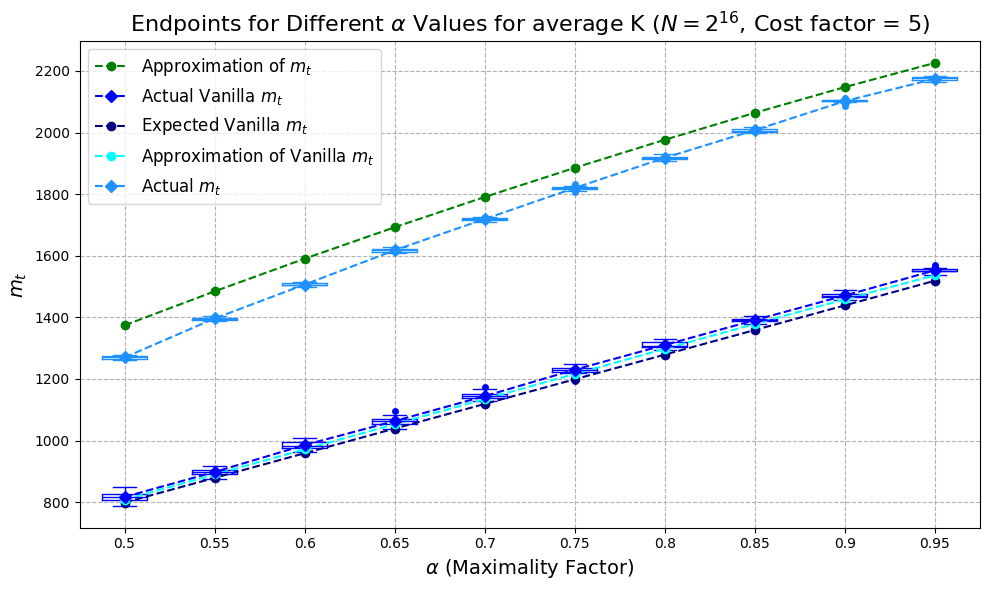

In [ ]:
# Plot box plot of actual MT results

x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

data_cherry = pd.read_csv("cherry_N_16_10_trials_average_K_different_alpha_0.5_0.95_with_cost_results.csv")

# # scatter plot for simulated optimisation mt
# plt.plot(x_indicies, optimisation_mt, color='orange', label='Optimisation $m_t$', zorder=2, linestyle='--', marker='o')
# scatter plot for approximation mt
plt.plot(x_indicies, approximation_mt, color='green', label='Approximation of $m_t$', zorder=2, linestyle='--', marker='o')
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[1:11]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),      
            medianprops=dict(color='dodgerblue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))

# For vanilla tables:
# plot box plot for actual vanilla mt from 20 trials
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='blue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=5, markeredgecolor='none'))
# plot means of vanilla boxplots
plt.plot(x_indicies, [data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten().mean() for alpha in alphas], 
         color='blue', marker='D', linestyle='--', label='Actual Vanilla $m_t$', zorder=3)
# plot expected vanilla from formula
plt.plot(x_indicies, expected_vanilla_mts, color='navy', label='Expected Vanilla $m_t$', zorder=2, linestyle='--', marker='o')
# plot approximation for vanilla
plt.plot(x_indicies, approximation_vanilla_mt, color='cyan', label='Approximation of Vanilla $m_t$', zorder=2, linestyle='--', marker='o')

# plot means of boxplots
plt.plot(x_indicies, [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[1:11]].values.flatten().mean() for alpha in alphas], 
         color='dodgerblue', marker='D', linestyle='--', label='Actual $m_t$', zorder=3)

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for average K ($N=2^{16}$, Cost factor = 5)', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()  
plt.show()

## Test 3

Test out vanilla tables (expected, approximate, and actual) for higher N and higher t
Try (depending on how long these take):
- N = 2^20
- N = 2^32
- N = 2^42

### Make the actual vanilla tables 

In [ ]:
def test_3_build_vanilla(N, t, n_label):
    samples = 10    # 10 samples
    generation_results = []
    generation_mt = []
    generation_costs = []
    startpoint_sets = []

    for a, alpha in enumerate(alphas):
        # build the actual table - sample times 
        # first generate starpoints and store them
        mt_max = (2*N)/(t+2)
        mt_target = alpha * mt_max
        vanilla_m_0 = round(mt_target/(1-alpha))    # our starting m_0
        this_alpha_startpoints = []
        # generate sample sets of starpoints
        for i in range(samples):
            starpoints = set()
            while len(starpoints) < (vanilla_m_0):
                starpoints.add(random.randint(0, N-1))

            this_alpha_startpoints.append(starpoints)
        # append to main list
        startpoint_sets.append(this_alpha_startpoints)

        ##############################################################

        # build the vanilla table sample times and store it for later
        this_alpha_tables = []
        this_alpha_mt = []
        this_alpha_costs = []

        # build sample tables
        for i in range(samples):
            # get starpoints
            starpoints = this_alpha_startpoints[i]
            # make the table with these startpoints
            table, hashes, reductions = build_vanilla_table_with_costs(N, t, starpoints)
            # append to this alpha's tables
            this_alpha_tables.append(table)
            this_alpha_mt.append(len(table))
            this_alpha_costs.append(hashes)  # total cost is hashes + reductions * 1/577.44
        
        # append to main list
        generation_results.append(this_alpha_tables)
        generation_mt.append(this_alpha_mt)
        generation_costs.append(this_alpha_costs)

    ###################################################################

    # store in a csv file
    with open(f"vanilla_N_{n_label}_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
        f_alpha = csv.writer(f) # create a csv writer

        # create a list of headers for the different trials
        trial_headers = []
        cost_headers = []
        for i in range(samples):
            trial_headers.append(f"trial_{i+1}")
            cost_headers.append(f"cost_{i+1}")
        
        f_alpha.writerow(["alpha"] + trial_headers + cost_headers)

        # add in data for each alpha
        for i in range(len(alphas)):
            row = [alphas[i]] + generation_mt[i] + generation_costs[i]
            f_alpha.writerow(row)


In [ ]:
n_labels = [20, 32, 42]
n_values = [2**20, 2**32, 2**42]
for i in tqdm(range(len(n_values)), desc="Testing vanilla builds for different N: "):
    # recalculate t for this N
    t = round(log(1-p)/log(1-n_values[i]**(-1/3)))
    test_3_build_vanilla(n_values[i], t, n_labels[i])


Testing vanilla builds for different N:   0%|          | 0/3 [00:00<?, ?it/s]

Testing vanilla builds for different N:  33%|███▎      | 1/3 [18:51:50<37:43:40, 67910.00s/it]


KeyboardInterrupt: 

## Test ?

Try test 2 again but for higher N and higher t to see if approximation is wrong because of using small values

### Redfine constants

In [ ]:
%%script false

N = 2 ** 32
t = 1000

Couldn't find program: 'false'


### Run Simulation

In [ ]:
%%script false

starpoint_sets = []
optimisation_results = []
optimisation_kis = []
optimisation_cost = []
optimisation_mt = []

for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 5, 1, t)
    optimisation_kis.append(kis)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, final_cost, m_values]
    optimisation_results.append(result)
    optimisation_cost.append(final_cost)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)

# store optimisation_results in a pickle file
with open("cherry_N_32_t_1000_different_alpha_0.5_0.95_optimisation_results.pkl", "wb") as f:
    pickle.dump(optimisation_results, f)

Couldn't find program: 'false'


### Find average K and calculate approximation results

In [ ]:
%%script false

# get average K_i for each column
K = []
for i in range(t):
    k_i = [optimisation_kis[j][i] for j in range(len(alphas))]
    K.append(sum(k_i)/len(k_i))

# get approximation results
approximation_mt = []
for alpha in alphas:

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    m_0 = round(mt_target/(1-alpha))    # our starting m_0

    approximation_mt.append(approximate_mt(N, t, K, m_0))

Couldn't find program: 'false'


### Build Cherry Tables for average K

In [ ]:
%%script false

samples = 10
generation_results = []
generation_mt = []
generation_costs = []
startpoint_sets = []

for a, alpha in enumerate(alphas):
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    startpoint_sets.append(this_alpha_startpoints)

    ##############################################################

    # build the cherry table sample times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []

    # build sample tables
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = build_cherry_table(N, t, starpoints, K)
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

###################################################################

# store in a csv file
with open("cherry_N_32_10_trials_average_K_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha"] + trial_headers + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i]] + generation_mt[i] + generation_costs[i]
        f_alpha.writerow(row)

Couldn't find program: 'false'


### Plot

In [ ]:
%%script false

# Plot box plot of actual MT results

x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

data_cherry = pd.read_csv("cherry_N_32_10_trials_average_K_different_alpha_0.5_0.95_with_cost_results.csv")

# # scatter plot for simulated optimisation mt
# plt.plot(x_indicies, optimisation_mt, color='orange', label='Optimisation $m_t$', zorder=2, linestyle='--', marker='o')
# scatter plot for approximation mt
plt.plot(x_indicies, approximation_mt, color='green', label='Approximation of $m_t$', zorder=2, linestyle='--', marker='o')
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[1:11]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),      
            medianprops=dict(color='dodgerblue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))

# plot means of boxplots
plt.plot(x_indicies, [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[1:11]].values.flatten().mean() for alpha in alphas], 
         color='dodgerblue', marker='D', linestyle='--', label='Actual $m_t$', zorder=3)

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for average K ($N=2^{32}$, Cost factor = 5)', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()  
plt.show()

Couldn't find program: 'false'
